## WP2.2 
### normalisation and standardisation of water quality measures. 

#### A: Instrument  to Intrument harmonisation:

PROCESS:

1. generate **daily** results for some sites, e.g. for the years 2019 & 2020 (all instruments available), and:
   - Save the results as cumulative distributions for all variables for all sites
     
   **-- COMPLETED --**
3. Compile and compare results for the same algorithm, between sensors, i.e,. :
   - NDVI ETM v. NDVI OLI v. NDVI MSI, and:
   - Select a REFERENCE measurement (usually the MSI version) for each measurement
     
    **-- COMPLETED --**
4. Determine offsets or adjustments to reach the reference (a function), and:
   - save functions that adjust for sensor differences
    **-- COMPLETED --**
5. (Choose sites to ***be re-used for calibration against in-situ data*** (e.g. lake victoria)

WHY IS THIS NEEDED?:

1. Multi-year time-series results will not be valid unless these corrections are made, because results are biased from one sensor to another.
   
Move on to harmonisation between measurements

 
#### B: Measurement to Measurement harmonisation :
1. generate results for all sites
   - results include the observed distribution of each WQ variable - this is in quantiles
3. compile results to a single dataset
4. choose a reference measrement
5. determine the adjustment parameters to adjust other measures to the statistical space of the reference measure
   - this includes the **time intervals** to use 
   - Simplest case: match the medians and the 1% quantile **for all times and places**
   - More sophisticated : match probability distributions to an ensemble model (pending)

In [2]:
# ---  dependencies --- 

import datacube
import numpy as np
import xarray as xr
import scipy as sp
import gc
import json
from scipy import stats
import pandas as pd     #for dates
from odc.ui import image_aspect
from deafrica_tools.plotting import rgb # used in some visualisation for debugging
#dc = datacube.Datacube(app='DoinWhatImdoin') #testing what difference the 'app' value makes...

In [3]:
# --- pathnames 
# results files are stored in my space for now
results_directory = '/home/jovyan/deafrica_water_quality/wq_results/'
WP12              = '/home/jovyan/dev/deafrica_water_quality/WP1.2'
WP22              = '/home/jovyan/dev/deafrica_water_quality/WP2.2'
all_results_filename    = 'wq_raw'
annual_results_filename  = 'annsummary'
parta_results_filename   = '22A'

In [4]:
# --- run code for functions that are called
%run /home/jovyan/dev/deafrica_water_quality/WP2.2/_WP2.2_functions.py   
%run /home/jovyan/dev/deafrica_water_quality/WP1.2/_WQ_functions.py

# Part A, Instrument to Instrument Harmonisation

## A1 : Build datasets from daily observations for key sites

- as well as the primary data, we are going to need wofs to determine water areas, and the geomedians to help filter outliers (perhaps).

#### Parameters -- including a list of places to process 
- parameters are needed for the accompanying geomedian datasets too
  

In [6]:
# --- controlling parameters and settings 
verbose = True 
test    = False
# --- the number of cells in the spatial domain (x,y) used to analyse the waterbody ; Data are resampled guided by this limit 
max_cells = 100000   
max_cells = 50000   #use this to test memory limits. Memory saving steps are going to be needed...
max_cells = 10000   #use this to test memory limits. Memory saving steps are going to be needed...
year1, year2 = '2019-01-01','2020-12-31' #this is a good start interval for instrument cross-referencing

# --- get the dictionary of all possible places for analysis ---
places_dict     = set_spacetime_domain()   
process_list = ['Lake_Baringo', 
           'Senegal_StLouis', 
           'Lake_Sulunga', 'Lake_Mweru',
            'Ghana_River', 
            'Lake_vic_turbid', 
            'Morocco', 
            'Thewaterskool_SA',
            'Ethiopia1of2', 
            'Ethiopia2of2', 
            'Ethiopia3of2',
            'SA_smalldam',
            'Lake Chamo', 
            'Lake Ziway', 
            'Lake Alwassa',
            'mombasa', 
            'Lake_Nasser_nth',
            'Lake_Nasser_sth',
            'Lake_Malawi',
            'Barrage Joumine', 
            'Lake_Chilwa', 'Lake_Malombe',
            'Indian_Ocean',
            'Haartbeesport_dam', 'Lake Bogoria',
            'HC_1',
            'HC_2',
            'HC_3',
            'HC_4',
            'HC_5',
            'HC_6']

In [7]:
# --- dictionaries for the non-geomedian instruments and products ...
instruments_to_use = {
    'oli_agm'  : {'use': False },
    'oli'      : {'use': True},
    'msi_agm'  : {'use': False },
    'msi'      : {'use': True},
    'tm_agm'   : {'use': False },
    'tm'       : {'use': True},
    'tirs'     : {'use': True},  
    'wofs_ann' : {'use': False },
    'wofs_all' : {'use': False },  # wofs_all will be removed as it is better to derive from wofs_ann
    }

# for the non-geomedian datasets, the build function wants to know the products ... 
instruments_to_use = check_instrument_dates(instruments_to_use,
                                            pd.DatetimeIndex([year1]).year[0],
                                            pd.DatetimeIndex([year2]).year[0],False)
products = { 
                'tm_agm'  :["gm_ls5_ls7_annual"],
                'tm'      :["ls5_sr","ls7_sr"],
                'oli_agm' :["gm_ls8_annual","gm_ls8_ls9_annual"],
                'oli'     :["ls8_sr","ls9_sr"],
                'msi_agm' :["gm_s2_annual"],
                'msi'     :["s2_l2a"],
                'tirs'    :["ls5_st","ls7_st","ls8_st","ls9_st"],
                'wofs_ann':["wofs_ls_summary_annual"],
                'wofs_all':["wofs_ls_summary_alltime"],
               }

instruments,measurements,rename_dict = instruments_list(instruments_to_use) 
data_list = {}

In [8]:
# start a log file
logfilename = 'parta_log.csv'
a_log = open_logfile(places_dict,
                     logfilename,
                     overwrite='False',   # alternatively use True or False
                     include_list=process_list)

#reduce the log file to the places we are specifically interested in; this seems messy
droplist = list(set(a_log.PlaceName) - set(process_list))

for name in droplist:   a_log.drop(a_log[a_log.PlaceName==name].index,inplace=True)
a_log.reset_index(inplace=True,drop=True)

In [283]:
# reset on log file to start again  (comment this in/out):
placename = 
#a_log.loc[a_log['PlaceName']==placename,'Status'] = 100

#### RUN THE MAIN PROCESS - this takes hours and requires a large sandbox 
- Results are generated for a 10-year geomedian series, and
- A 1-year full-data series
- The full data series allows comparison of TM, OLI and MSI results for a common period.
- The full detail is required because the geomedians don't overlap in time.  

In [17]:
# this process first builds the supporting AGM dataset and then builds the specific dataset
over_write = False # to overwrite previous results
restart    = False # when notebook is fresh
verbose    = False
for placename in a_log.PlaceName:
    print(placename)
    if restart:
        a_log.loc[a_log['PlaceName']==placename,'Status'] = 0    
        
    if a_log.loc[a_log.PlaceName==placename,'Status'].item() < 100 :
        results_filename = parta_results_filename+'_'+placename+'_agm'+'.nc'
        print('Results will be saved in: '+results_directory+results_filename) 
        if os.path.exists(results_directory+results_filename) : 
            print('Results already exist for: '+results_filename)
            if not over_write :
                print('... '+placename+' will not be re-processed')
                a_log = log_update(a_log,placename,100,logfilename)
            else:
                print('... '+placename+' will be re-processed (over_write is set to True)')

        spacetime_domain, grid_resolution, cell_area, resampling_option, year1, year2 \
                           = set_spacetime_domain(placename,year1,year2,max_cells,verbose,False)
        parameters = store_parameters(placename,
                                          spacetime_domain,
                                          grid_resolution,
                                          cell_area,
                                          resampling_option,
                                          year1,
                                          year2)

        # --- set the years and instruments for the geomedian data
        # --- the basics are stashed away in this function:
        gm_years,gm_instruments_to_use = geomedian_instruments_and_years(parameters)
        # --- different years are needed for the geomedians to give a 5 year interval
        gm_parameters = parameters              # --- store the parameters for reference 
        gm_parameters['year1'] = gm_years[0]
        gm_parameters['year2'] = gm_years[1]
        # --- check the proposed years against the geomedian dataset dates ---
        gm_instruments_to_use = check_instrument_dates(gm_instruments_to_use,gm_years[0],gm_years[1],verbose=False)
        # --- get the full detail, the gm_instruments is used later, the other parts not 
        gm_instruments,gm_measurements,gm_rename_dict   = instruments_list(gm_instruments_to_use)
        
        i = 1 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            print('... building the geomedian dataset for '+placename)
            ds_annual = build_agm_dataset(gm_parameters,gm_instruments_to_use)
            a_log = log_update(a_log,placename,i,logfilename)

        i = 2 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            ds_annual = detect_geomedian_instruments(ds_annual)
            a_log = log_update(a_log,placename,i,logfilename)

        i = 3 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            ds_annual = calculate_agm_count(ds_annual)
            a_log = log_update(a_log,placename,i,logfilename)
            a_log = log_update(a_log,placename,i,logfilename)
 

        i = 4
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
        # --- controling parameters for water mapping on a pixel by pixel basis ---
            WFTH = water_frequency_threshold_high = 0.5    #this threshold targets areas that are as like as not to be water at any time.
            PWT  = permanent_water_threshold      = 0.875  #used to map annual permanent water (value arrived at through testing)
            SC   = sigma_coefficient              = 1.2    #used to map annual permanent water (value arrived at through tessting)
            ds_annual   = water_analysis(ds_annual,
                   water_frequency_threshold= WFTH,
                   wofs_varname             = 'wofs_ann_freq',
                   permanent_water_threshold= PWT,
                   sigma_coefficient        = SC,
                   verbose                  = True,
                   test                     = test)
            a_log = log_update(a_log,placename,i,logfilename)

        i = 5 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            ds_annual              = WOFS_5_year_frequency(ds_annual,False)
            a_log = log_update(a_log,placename,i,logfilename)

        i = 6 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            ds_annual['water_5yr'] = xr.where(ds_annual.wofs_5yr_freq>0.45,
                                                  ds_annual.wofs_5yr_freq.astype('bool'),np.nan)
            a_log = log_update(a_log,placename,i,logfilename)

        i = 7 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            ds_annual              = geomedian_FAI(ds_annual,ds_annual.water_5yr)
            ds_annual              = geomedian_NDVI(ds_annual,ds_annual.water_5yr)
            a_log = log_update(a_log,placename,i,logfilename)

        i = 8 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            ds_annual              = set_clearwater(ds_annual,'agm_fai','water_5yr','wofs_ann_water')
            a_log = log_update(a_log,placename,i,logfilename)

        i = 9 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:      
            ds_annual              = apply_R_correction(ds_annual,['msi_agm','oli_agm','tm_agm'],
                             water_mask=ds_annual.water_5yr,drop = True, test = False,verbose=False)
            a_log = log_update(a_log,placename,i,logfilename)

        i = 10
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            ds_annual = geomedian_hue(ds_annual,ds_annual.clearwater==True,test=False,verbose=True)
            a_log = log_update(a_log,placename,i,logfilename)

        i = 11 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            ds_annual = run_OWT(ds_annual,agm=True,verbose=True)
            a_log = log_update(a_log,placename,i,logfilename)

        i = 12 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i and True:
            print('running wq algorithms')
            algorithms_chla,algorithms_tsm = set_wq_algorithms(suffix='_agm')
            dummy,tsm_vlist  = WQ_vars(ds_annual.where(ds_annual.clearwater),
                        algorithms_tsm,  
                        gm_instruments, 
                        new_dimension_name=None, 
                        new_varname       =None, 
                        verbose=verbose)
            # this two-step process avoids masking other variables
            ds_annual[tsm_vlist] = dummy[tsm_vlist] 
            
            dummy,chla_vlist = WQ_vars(ds_annual.where(ds_annual.clearwater),
                        algorithms_chla, 
                        gm_instruments, 
                        new_dimension_name=None, 
                        new_varname       =None,
                        verbose=verbose)
            ds_annual[chla_vlist] = dummy[chla_vlist]
            del dummy

            a_log = log_update(a_log,placename,i,logfilename)
            
        i  = 14 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            agm_stats      = calc_agm_cumulative_distributions(ds_annual,
                                                               placename,
                                                               list(chla_vlist) + list(tsm_vlist))
            a_log          = log_update(a_log,placename,i,logfilename)                      
        
        i  = 15
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            save_results(agm_stats,results_filename,results_directory)
            print(placename + ' -> results for agm dataset saved to: '+results_filename) 
            a_log = log_update(a_log,placename,i,logfilename)       
            
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            print(' this should not happen')
        
        # -------- -------------------------------------------------------
        # -------- -------------------------------------------------------
                  
        print(placename+' - > Processing the main datasets...')
        results_filename = parta_results_filename+'_'+placename+'.nc'
        # confirm the instruments to use 
        instruments_to_use = check_instrument_dates(instruments_to_use,
                               pd.DatetimeIndex([parameters['xyt']['time'][0]]).year[0],
                               pd.DatetimeIndex([parameters['xyt']['time'][1]]).year[0],
                               verbose=False)

        # retreive the details of the instruments, measurements and renaming of variables
        instruments,measurements,rename_dict   = instruments_list(instruments_to_use)

        #---------------------------------------------------------------
        i = 16
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:

            # build the datasets which are saved in a dictionary
            data_list             = build_dataset(spacetime_domain,
                                           instruments_to_use,
                                           products,
                                           measurements,
                                           grid_resolution,
                                           resampling_option,
                                           rename_dict,
                                           verbose = True)
            a_log          = log_update(a_log,placename,i,logfilename)                      

        #---------------------------------------------------------------
        i = 17
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:

            # combine the datasets 
            ds = add_vars_and_combine_datasets(data_list)


            a_log          = log_update(a_log,placename,i,logfilename)                      

        #---------------------------------------------------------------
        i = 18
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            # Remove the original datasets
            del data_list
            gc.collect()
            a_log          = log_update(a_log,placename,i,logfilename)                      

        #---------------------------------------------------------------
        i = 19
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:

            # calculate the woter area
            #   and, the proportion of the water area with valid data
            #   and, the proportion of valid data that pass QA

            ds = determine_water_area (ds,ds_annual)

            a_log          = log_update(a_log,placename,i,logfilename)                      

        #---------------------------------------------------------------
        i = 20
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            # Filter dates where the proportion of good data is low
            # This serves to remove outliers in the data, as well as reducing memory use
            qa_percent_threshold = 0.2
            ds = ds.where(ds['data_qapass'] > qa_percent_threshold,drop=True)
            gc.collect()
            a_log          = log_update(a_log,placename,i,logfilename)                      

        #---------------------------------------------------------------
        i = 21
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            # calculate the NDVI 
            ds = calc_ndvi(ds,ds.water_5yr,threshold=0)

            # calculate the FAI 
            ds = calc_fai(ds,ds.water_5yr,threshold=0)

            ds = set_clearwater(ds,'fai','water_5yr','water_ann')

            a_log          = log_update(a_log,placename,i,logfilename)                      

        #---------------------------------------------------------------
        i = 22
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            # apply rayleigh correction
            ds = apply_R_correction(ds,['msi','oli','tm'],ds.clearwater,drop=True,test=False)

            # calculate hue values ... 

            ds['hue'] = ('y','x','time'), np.zeros((ds.sizes['y'],ds.sizes['x'],ds.sizes['time']))
            ds['hue'] = ds.hue * np.nan
            for instr in 'tm','msi','oli':
                ds['hue'] = xr.where(ds[instr]==True,
                      hue_calculation(ds,instr),
                      ds.hue)


            # for OWT, the clearwater mask is assumed in the dataset
            ds = run_OWT(ds,agm=False,verbose=True)
            a_log          = log_update(a_log,placename,i,logfilename)                      

        #---------------------------------------------------------------

        i = 23
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            print('running wq algorithms')
            algorithms_chla,algorithms_tsm = set_wq_algorithms(suffix='')
            dummy,tsm_vlist  = WQ_vars(ds.where(ds.clearwater),
                        algorithms_tsm,  
                        instruments, 
                        new_dimension_name=None, 
                        new_varname=None, 
                        verbose=verbose,
                        test=False)
            

            # this two-step process avoids masking other variables
            ds[tsm_vlist] = dummy[tsm_vlist]
            del(dummy)
            gc.collect()

            dummy,chla_vlist = WQ_vars(ds.where(ds.clearwater),
                        algorithms_chla, 
                        instruments, 
                        new_dimension_name=None, 
                        new_varname=None,
                        verbose=verbose,
                        test=False)
            ds[chla_vlist] = dummy[chla_vlist]
            del dummy
            gc.collect()
            a_log          = log_update(a_log,placename,i,logfilename)                      

        #---------------------------------------------------------------
        i = 24
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            stats = calc_cumulative_distributions(ds,placename,list(chla_vlist) + list(tsm_vlist))
 

        #---------------------------------------------------------------
        i = 25
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            save_results(stats,results_filename,results_directory)
            print(placename+' -> results for dataset saved to: '+results_filename) 
            a_log = log_update(a_log,placename,i,logfilename)       
             
        #---------------------------------------------------------------
        i = i
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            pass
        a_log = log_update(a_log,placename,100,logfilename)       
        print(placename+'  -> COMPLETED')


# for some reason the log file is picking up unwanted columns which this removes!
for colname in a_log.columns:
    if colname.find('Unnamed:') >= 0:
         a_log = a_log.drop([colname],axis=1)
a_log = log_update(a_log,placename,i,logfilename)

Haartbeesport_dam
HC_1
HC_2
HC_3
HC_4
HC_5
HC_6
Lake_Baringo
Senegal_StLouis
Lake_Sulunga
Lake_Mweru
Ghana_River
Lake_vic_turbid
Morocco
Thewaterskool_SA
Ethiopia1of2
Ethiopia2of2
Ethiopia3of2
SA_smalldam
Lake Chamo
Lake Ziway
Lake Alwassa
mombasa
Lake_Nasser_nth
Lake_Nasser_sth
Lake_Malawi
Barrage Joumine
Lake_Chilwa
Lake_Malombe
Indian_Ocean
Results will be saved in: /home/jovyan/deafrica_water_quality/wq_results/22A_Indian_Ocean_agm.nc
Results already exist for: 22A_Indian_Ocean_agm.nc
... Indian_Ocean will not be re-processed
Indian_Ocean - > Processing the main datasets...
Indian_Ocean  -> COMPLETED
Lake Bogoria
Results will be saved in: /home/jovyan/deafrica_water_quality/wq_results/22A_Lake Bogoria_agm.nc
... building the geomedian dataset for Lake Bogoria

Building the Geomedian dataset:
loading data for  oli_agm ...
loading data for  msi_agm ...
loading data for  wofs_ann ...


/opt/venv/lib/python3.12/site-packages/xarray/core/duck_array_ops.py:250: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


---variable -->   msi01_agm   <-- anticipated but not found in the dataset (non-fatal)
---variable -->   oli01_agm   <-- anticipated but not found in the dataset (non-fatal)

 Aborting hue calculation for instrument  oli  due to lack of necessary data bands


 calculating optical water type (OWT), sensor =  msi  ....

....done
Prevailng water type is  3.0  :   oligotrophic (clear)

 calculating optical water type (OWT), sensor =  oli  ....

....done
Prevailng water type is  3.0  :   oligotrophic (clear)
running wq algorithms


/opt/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/opt/venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1601: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


Lake Bogoria -> results for agm dataset saved to: 22A_Lake Bogoria_agm.nc
Lake Bogoria - > Processing the main datasets...
building the oli dataset...
... done.
building the msi dataset....
... done.
building the tm dataset ...
... done.
Data list =  dict_keys(['oli', 'msi', 'tm']) 

... instrument datasets complete

---variable -->   msi01   <-- anticipated but not found in the dataset (non-fatal)

 calculating optical water type (OWT), sensor =  msi  ....

....done
Prevailng water type is  1.0  :   eutrophic and blue-green

 calculating optical water type (OWT), sensor =  oli  ....

....done
Prevailng water type is  4.0  :   eutrophic and blue-green

 calculating optical water type (OWT), sensor =  tm  ....

....done
Prevailng water type is  3.0  :   oligotrophic (clear)
running wq algorithms


/opt/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


Lake Bogoria -> results for dataset saved to: 22A_Lake Bogoria.nc
Lake Bogoria  -> COMPLETED


In [18]:
ds_annual

<xarray.Dataset> Size: 56MB
Dimensions:              (time: 10, y: 203, x: 66)
Coordinates:
  * time                 (time) datetime64[ns] 80B 2015-07-02T11:59:59.999999...
  * y                    (y) float64 2kB 2.282e+04 2.294e+04 ... 4.504e+04
  * x                    (x) float64 528B 3.479e+06 3.479e+06 ... 3.486e+06
    spatial_ref          int32 4B 6933
Data variables: (12/73)
    oli05_agm            (time, y, x) float64 1MB 1.677e+03 ... 2.268e+03
    oli06_agm            (time, y, x) float64 1MB 1.95e+03 ... 1.221e+03
    oli07_agm            (time, y, x) float64 1MB 1.514e+03 1.61e+03 ... 607.0
    oli_agm_smad         (time, y, x) float32 536kB 0.0007695 ... 0.003295
    oli_agm_emad         (time, y, x) float32 536kB 183.0 178.0 ... 435.0 458.0
    oli_agm_bcmad        (time, y, x) float32 536kB 0.02677 0.02538 ... 0.06547
    ...                   ...
    chla_3bda_msi        (time, y, x) float32 536kB nan nan nan ... nan nan nan
    chla_3bda_oli        (time, y, x) float64 1MB nan nan nan ... nan nan nan
    chla_tebbs_msi       (time, y, x) float32 536kB nan nan nan ... nan nan nan
    chla_tebbs_oli       (time, y, x) float64 1MB nan nan nan ... nan nan nan
    chla_meris2b_msi     (time, y, x) float32 536kB nan nan nan ... nan nan nan
    chla_modis2b_msi     (time, y, x) float32 536kB nan nan nan ... nan nan nan
Attributes:
    crs:           epsg:6933
    grid_mapping:  spatial_ref

#### EXAMINE SOME RESULTS  - purely for visual checking purposes 
-   

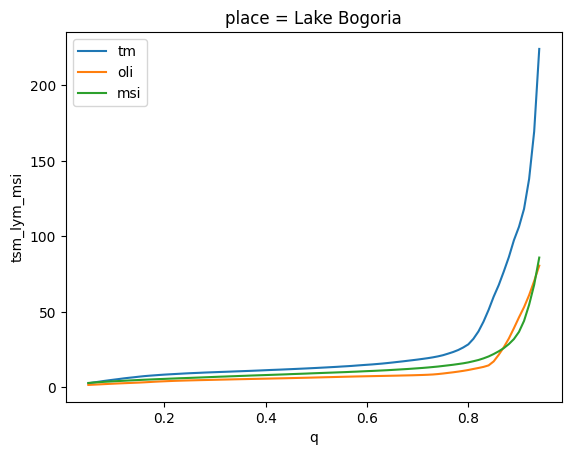

In [19]:
for instr in 'tm','oli','msi':
    stats['tsm_lym_'+instr].loc[:,.05:.95].plot(label=instr)
plt.legend()
plt.show()


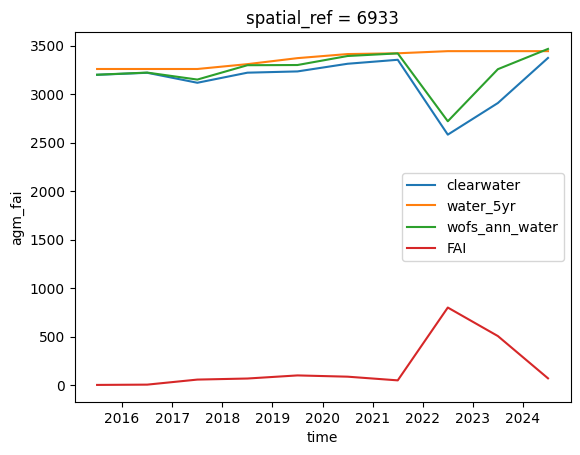

In [20]:
# this plot confirms that the water masks are behaving properly 
# which is vital to exclude non-target data resutls
ds_annual.where(ds_annual.clearwater==True).clearwater.count(dim=('x','y')).plot(label='clearwater')
ds_annual.where(ds_annual.water_5yr==True).water_5yr.count(dim=('x','y')).plot(label='water_5yr')
ds_annual.where(ds_annual.wofs_ann_water>0).wofs_ann_water.count(dim=('x','y')).plot(label='wofs_ann_water')
ds_annual.where(ds_annual.agm_fai>0).agm_fai.count(dim=('x','y')).plot(label='FAI')
plt.legend()
plt.show()

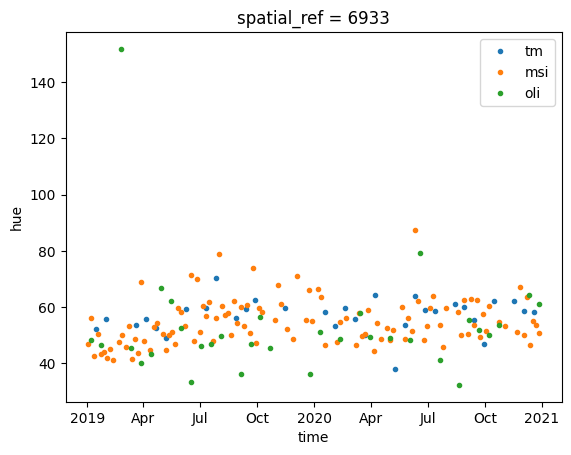

In [21]:
#ds.hue.loc[ds[instr] ==True].median(dim=('x','y')).plot()
for inst in 'tm','msi','oli':
    ds.where(ds.clearwater==True).hue.loc[ds[inst]==True].median(dim=('x','y')).\
        plot(label = inst,marker='.',linestyle='')
plt.legend()
plt.show()

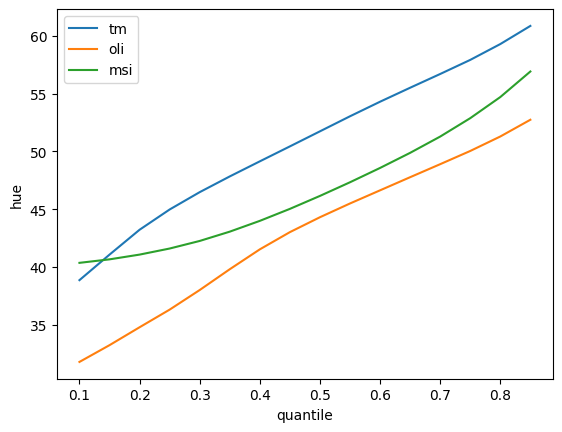

In [22]:
for inst in 'tm','oli','msi':
    ds.where(ds.water_5yr).where(ds[inst]==True).hue.quantile(np.arange(0.1,.90,0.05),dim=('x','y','time')).plot(label=inst)
plt.legend()
plt.show()

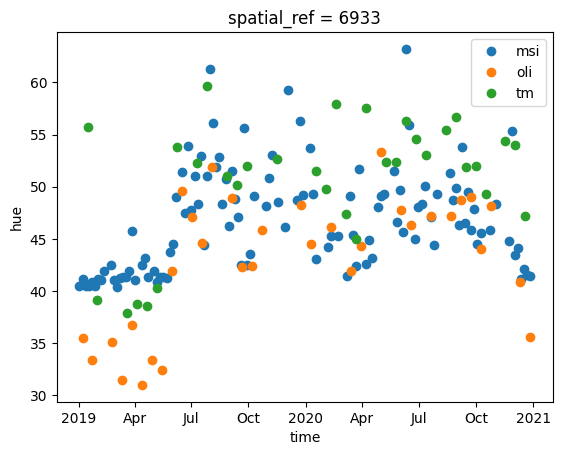

In [23]:
for inst in 'msi','oli','tm' :
    ds.where(ds.water_5yr).hue.loc[ds[inst]==True].median(dim=('x','y')).plot(linestyle='',marker='o',label=inst)
#ds.fai.loc[ds.tm==True].median(dim=('x','y')).plot(linestyle='',marker='d',label='tm')
plt.legend()
plt.show()

## A2 : Compile the results and choose a reference for each variable
- This is quite a manual process 

In [24]:
# --- run code for functions that are called
%run /home/jovyan/dev/deafrica_water_quality/WP2.2/_WP2.2_functions.py   

### Read the log file to see which sites have been processed 
- results data should be available for any sites with a Status of 100

In [25]:
pd.read_csv('/home/jovyan/dev/deafrica_water_quality/WP2.2/parta_log.csv')

,Unnamed: 0,PlaceName,Status,RunNumber,Year1,Year2
0,0,Haartbeesport_dam,100,0,0,0
1,1,HC_1,100,0,0,0
2,2,HC_2,100,0,0,0
3,3,HC_3,100,0,0,0
4,4,HC_4,100,0,0,0
5,5,HC_5,100,0,0,0
6,6,HC_6,100,0,0,0
7,7,Lake_Baringo,100,0,0,0
8,8,Senegal_StLouis,100,0,0,0
9,9,Lake_Sulunga,100,0,0,0


### Merge the results from all sites into a single results dataset 
- results data should be available for any sites with a Status of 100
- dataset dimensions are :
  - 'place' (one place for each site)
  - 'q' for quantile (q has values of 0, 0.01, .... 1.00), capturing the cumulative distribution of the variable
- dataset variables will be all the WQ variables
- **SAVE** this locally to '22A.nc'

In [26]:
# --- A function that reads results for a given  site
def read_statsfile(filename,pathname):
    suffix = '.nc'
    fname = pathname+filename+suffix 
    if os.path.exists(fname) :
        #print('opening '+fname)
        ds = xr.open_dataset(fname).load(); ds.close()
        #print('file found')
        return(ds)

In [27]:
# --- A function that reads all results files and merges to a single dataset of about 1MB in size
def merge_stats(log,filename,pathname,overwrite=True,verbose=True,test=False):
    suffix = '.nc'
    start = -1
    fname = pathname+filename+suffix 
    if not overwrite : 
        if os.path.exists(fname) :
            if test : print('existing file found',fname)
            dsr = read_statsfile(filename,pathname)
            start = 0
    for i in log.index.to_list() :
        placename = log.loc[i,'PlaceName']
        if verbose: print('Looking for '+placename)
        fname     = pathname+filename+'_'+placename+suffix
        if os.path.exists(fname) :
            if verbose: print('... found ')
            
            if  start < 0 :
                start = i
                dsr   = read_statsfile(filename+'_'+placename,pathname)
                if test: print(type(dsr))
            else :
                dsr=dsr.combine_first(read_statsfile(filename+'_'+placename,pathname))
    dsr.to_netcdf(pathname+filename+suffix)
    return(dsr)    

In [28]:
# ---- Merge distributions (from all the sample places) and write to .nc file
# ---------------------------------------------------------------------------------------------
a_log = pd.read_csv('/home/jovyan/dev/deafrica_water_quality/WP2.2/parta_log.csv')
all_results_filename = '22A'
results_directory = '/home/jovyan/deafrica_water_quality/wq_results/'

wq_stats = merge_stats(a_log,all_results_filename,results_directory)

#save in the work-package area:
wq_stats.to_netcdf('/home/jovyan/dev/deafrica_water_quality/WP2.2/targ_ref_lookup.csv')

# --- the overall distributions are calculated as the weighted mean of each quantile for the observed data ---
distributions = wq_stats.drop_dims('place')
for variable in wq_stats.data_vars:
    if 'q' in wq_stats[variable].sizes :
        distributions[variable] =  (wq_stats.loc[{'q':wq_stats.q[0:101]}][variable] * wq_stats.n).sum(dim='place') / wq_stats.n.sum()

# ---- write the final distributions to a netcdf file 
distributions.to_netcdf('distributions.nc')

Looking for Haartbeesport_dam
... found 
Looking for HC_1
... found 
Looking for HC_2
... found 
Looking for HC_3
... found 
Looking for HC_4
... found 
Looking for HC_5
... found 
Looking for HC_6
... found 
Looking for Lake_Baringo
... found 
Looking for Senegal_StLouis
... found 
Looking for Lake_Sulunga
... found 
Looking for Lake_Mweru
... found 
Looking for Ghana_River
... found 
Looking for Lake_vic_turbid
... found 
Looking for Morocco
... found 
Looking for Thewaterskool_SA
... found 
Looking for Ethiopia1of2
... found 
Looking for Ethiopia2of2
... found 
Looking for Ethiopia3of2
... found 
Looking for SA_smalldam
... found 
Looking for Lake Chamo
... found 
Looking for Lake Ziway
... found 
Looking for Lake Alwassa
... found 
Looking for mombasa
... found 
Looking for Lake_Nasser_nth
... found 
Looking for Lake_Nasser_sth
... found 
Looking for Lake_Malawi
... found 
Looking for Barrage Joumine
... found 
Looking for Lake_Chilwa
... found 
Looking for Lake_Malombe
... found 


### Prove the harmonisation methods (i.e., effective adjustment of statistical distributions)
- Step 1: Quantiles from multiple sites are combined as a weighted mean
- Step 2: The merged distributions are matched
- Step 3: The results are plotted


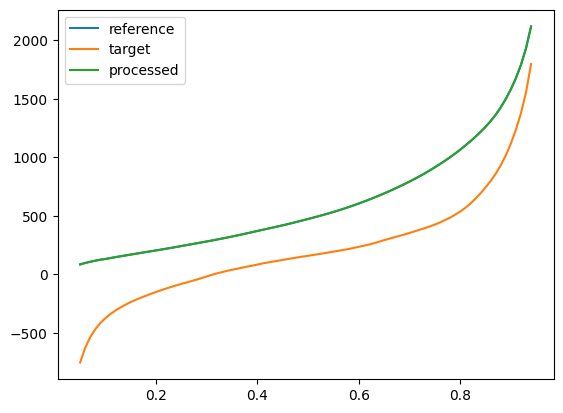

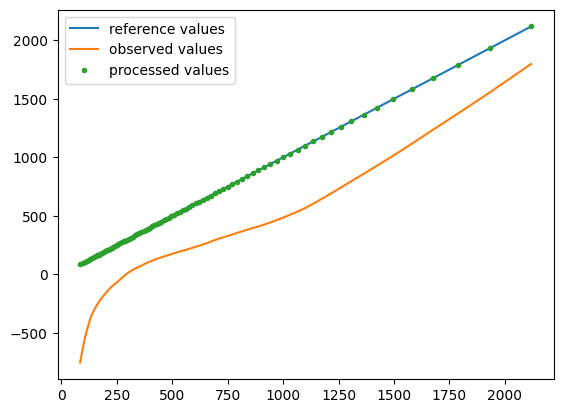

In [29]:
# Run the steps as described....

target  = 'chla_tebbs_oli'
reference = 'chla_tebbs_msi'
q0 = 5
q1 = 95

# Step 1 :Quantiles from multiple sites are combined as a weighted mean ---------------

target_dist_wm = ((wq_stats.loc[{'q':wq_stats.q[q0:q1]}][target] * wq_stats.n).sum(dim='place') / wq_stats.n.sum())
reference_dist_wm = ((wq_stats.loc[{'q':wq_stats.q[q0:q1]}][reference] * wq_stats.n).sum(dim='place') / wq_stats.n.sum())

target_dist    =  wq_stats.loc[{'q':wq_stats.q[q0:q1]}][target].mean(dim='place')
reference_dist =  wq_stats.loc[{'q':wq_stats.q[q0:q1]}][reference].mean(dim='place')
Q  = wq_stats.q[q0:q1]


# Step 2: The merged distributions are matched ---------

if True:
    method = 'quadratic'
    # --- fit a model to X; ie Q = f(x)
    f = sp.interpolate.interp1d(target_dist_wm,Q,kind=method,fill_value='extrapolate')
    # --- fit an inverse model to Y; ie Y = g(Q)
    g = sp.interpolate.interp1d(Q,reference_dist_wm,kind=method,fill_value='extrapolate')
    # --- new values are given by g(f(x)), which is very cool 

processed_dist = g(f(target_dist_wm))

# Step 3: the results are plotted -

plt.plot(Q,reference_dist_wm,label='reference')
plt.plot(Q,target_dist_wm,label='target')
plt.plot(Q,processed_dist,label='processed')
plt.legend()
plt.show()

plt.plot(reference_dist_wm,reference_dist_wm,label='reference values')
plt.plot(reference_dist_wm,target_dist_wm,label='observed values')
plt.plot(reference_dist_wm,processed_dist,label='processed values',linestyle='',marker='.')
plt.legend()
plt.show()




### Implement the harmonistaion method as a function
- A reference table that relates each variable to a reference variable
    - e.g. 'tsm_lym_oli' and 'tsm_lym_tm' would be referenced to 'tsm_lym_msi'
    - saved as the table called 'targ_ref_lookup.csv'

- A function to adjust the values of an input array
- Run the function

In [30]:
# ---- Build a lookup table for target and reference variables (once only)

# --- Specify the target-reference relationships here! ----
namearray  = np.array([
['ndci_msi54'      , 'ndci_msi74'],
['ndci_msi64'      , 'ndci_msi74'],   # the 64 mmt is very close to 74
['ndci_msi74'      , 'ndci_msi74'],  
['ndci_tm43'       , 'ndci_msi74'],
['ndci_oli54'      , 'ndci_msi74'],
['chla_toming_msi' , 'chla_toming_msi'],
['chla_3bda_msi'   , 'chla_3bda_msi'],
['chla_3bda_oli'   , 'chla_3bda_msi'],
['chla_3bda_tm'    , 'chla_3bda_msi'],
['chla_tebbs_msi'  , 'chla_tebbs_msi'],
['chla_tebbs_oli'  , 'chla_tebbs_msi'],
['chla_tebbs_tm'   , 'chla_tebbs_msi'],
['chla_meris2b_msi', 'chla_meris2b_msi'],
['chla_modis2b_msi', 'chla_modis2b_msi'],
['chla_modis2b_tm' , 'chla_modis2b_msi'],
['ndssi_rg_msi'    , 'ndssi_rg_msi'],
['ndssi_rg_oli'    , 'ndssi_rg_msi'],
['ndssi_rg_tm'     , 'ndssi_rg_msi'],
['ndssi_bnir_oli'  , 'ndssi_rg_msi'],    # this bnir_oli does not behave well; this will mitigate but we could leave it out altogether
['ti_yu_oli'       , 'ti_yu_oli'],
['ti_yu_tm'        , 'ti_yu_oli'],
['tsm_lym_oli'     , 'tsm_lym_msi'],
['tsm_lym_msi'     , 'tsm_lym_msi'],
['tsm_lym_tm'      , 'tsm_lym_msi'],
['tss_grb_msi'     , 'tss_grb_msi'],
['tss_grb_oli'     , 'tss_grb_msi'],
['tss_grb_tm'      , 'tss_grb_msi'],
['tss_gr_msi'      , 'tss_gr_msi'],
['tss_gr_oli'      , 'tss_gr_msi'],
['tss_gr_tm'       , 'tss_gr_msi'],
['spm_qiu_tm'      , 'spm_qiu_msi'],
['spm_qiu_msi'     , 'spm_qiu_msi'],
['fai_tm'          , 'fai_msi'],
['fai_oli'         , 'fai_msi'],
['fai_msi'         , 'fai_msi'],
['ndvi_tm'         , 'ndvi_tm'],
['ndvi_oli'        , 'ndvi_tm'],
['ndvi_msi'        , 'ndvi_tm'],
['hue_tm'          , 'hue_msi'],
['hue_oli'         , 'hue_msi'],
['hue_msi'         , 'hue_msi']])

# build a lookup table for target and reference variables
lookup = pd.DataFrame(columns= ['target','reference'],data = namearray)

# save the lookup table in the local directory:
lookup.to_csv('/home/jovyan/deafrica_water_quality/wq_results/targ_ref_lookup.csv')

lookup.to_csv('/home/jovyan/dev/deafrica_water_quality/WP2.2/targ_ref_lookup.csv')

In [222]:
# --- 'harmonise_for_instrument' adjusts the values of an array  ----
# the adjustment ensures that, statistically, the returned values have the same distribution (mean, variance) as the reference
# 
def harmonise_for_instrument(da,           # the input data array
                             varname,      # the name of the variable as it appears in the lookup table
                             lookup_table, #the lookup table (a pandas data frame) used to find the reference variable that corresponds to the variable
                             distributions # the dataset of cumulatibve probability distributions used to determine the transformation
                            ): 
    # --- find the target variable
    if not varname in list(lookup.target):
        print(varname+' not found, data unchanged')
        return(da)

 
    refname = lookup[lookup.target==varname]['reference'].item()
    print(varname,refname)
    Q              = distributions.q 
 
    method = 'linear'    # quadratic may be okay but should not be necessary
    method = 'quadratic'    # quadratic may be okay but should not be necessary

    # control which parts of the distribution we  mnodel
    
    # --- fit a model to X; ie Q = f(x); limit the valid range of the function with excess values being set to 0 or 1
    i,j = 0,101  # use all quantiles in this part
    f = sp.interpolate.interp1d(distributions[varname][i:j],Q[i:j],kind=method,bounds_error = False,fill_value = (0,1))
    #f = sp.interpolate.interp1d(distributions[varname][i:j],Q[i:j],kind=method,bounds_error = False)
    
    # --- fit an inverse model to Y; ie Y = g(Q).  Fi
    k,l = 1,101  # limit the data values here to the 99th percentile to avoid extreme values contaminating the process
    g = sp.interpolate.interp1d(Q[k:l],distributions[refname][k:l],kind=method,bounds_error=False)
    
    
    # --- create a new variable as a data array that matches the one provided, so that we can return a nice array
    return(
        xr.DataArray(data=g(f(da)), dims=da.dims,coords = da.coords,name = da.name+'_h')
        )

In [32]:
# --- run the function, first reading the lookup table and the distributions data from files

#preliminary steps, read the lookup table and the disttibutions data
lookup        = pd.read_csv('/home/jovyan/dev/deafrica_water_quality/WP2.2/targ_ref_lookup.csv',index_col=0)
distributions = xr.open_dataset('distributions.nc').load(); distributions.close()

example = harmonise_for_instrument(ds.hue.loc[ds.tm==True],'hue_msi',lookup,distributions)

hue_msi hue_msi


#### Check some statistical and spatial outputs


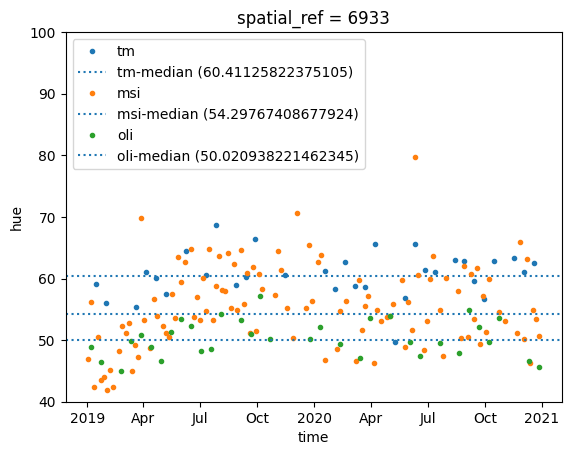

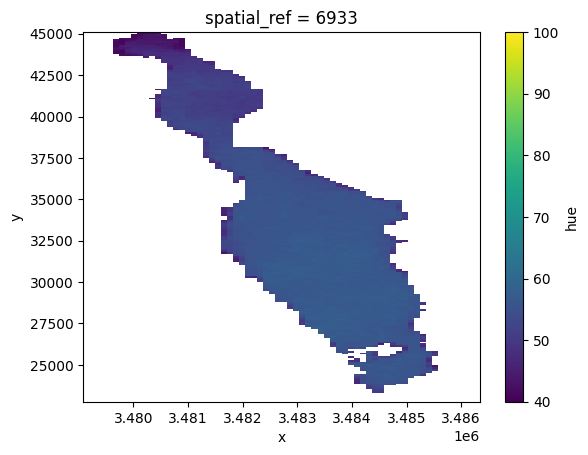

In [182]:
# before
#ds.hue.loc[ds[instr] ==True].median(dim=('x','y')).plot()
itemnumber = 0
params = [['hue',40,100],['ndvi',0,.6],['fai',0,.5]][itemnumber]
name,y0,y1   = params[0:3]
for inst in 'tm','msi','oli':
    ds.where(ds.water_5yr==True)[name].loc[ds[inst]==True].median(dim=('x','y')).plot(label = inst,marker='.',linestyle='')
    median_value = ds.where(ds.water_5yr==True)[name].loc[ds[inst]==True].median(dim=('x','y','time')) 
    l = str(inst+'-median ('+ str(median_value.item()) +')')
    plt.axhline(median_value,linestyle=':',label=l)
plt.ylim(y0,y1)
plt.legend()
plt.show()
ds.where(ds.water_5yr==True)[name].median(dim='time').plot(vmin=y0,vmax=y1)

hue_tm hue_msi
hue_msi hue_msi
hue_oli hue_msi


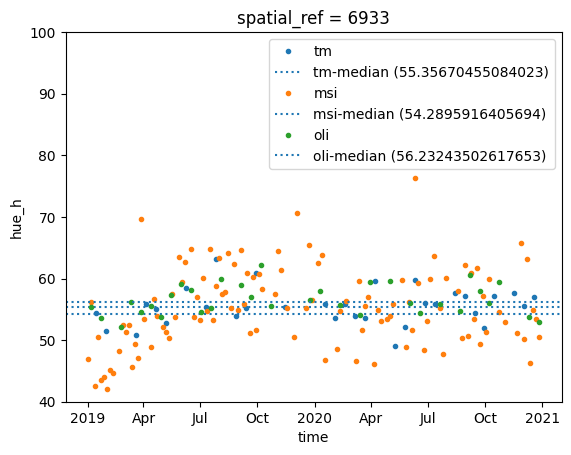

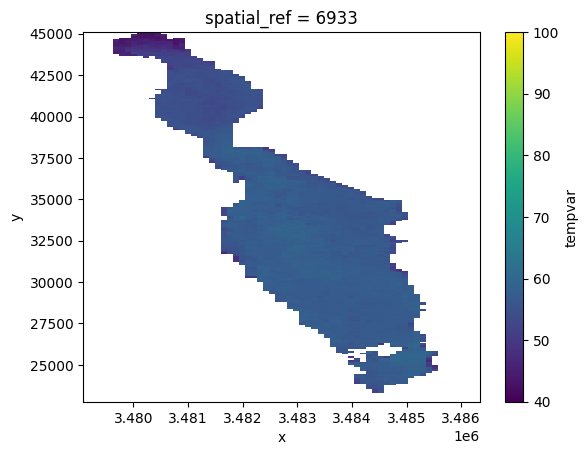

In [183]:
# After
#ds.hue.loc[ds[instr] ==True].median(dim=('x','y')).plot()
ds['tempvar'] = ds[name] * np.nan

for inst in 'tm','msi','oli':
    new = harmonise_for_instrument(
        #ds.where(ds.clearwater==True).hue.loc[ds[inst]==True],
        ds.where(ds.water_5yr==True).where(ds[inst]==True)[name],
        name+'_'+inst,
        lookup,distributions)
    new.median(dim=('x','y')).\
        plot(label = inst,marker='.',linestyle='')
    median_value = new.median() 
    plt.axhline(median_value,linestyle=':',label= str(inst+'-median ('+ str(median_value.item()) +')')
    )
    ds['tempvar'] = xr.where(ds[inst]==True,new,ds.tempvar)
plt.ylim(y0,y1)
plt.legend()
plt.show()
ds.where(ds.water_5yr==True).where(ds[inst]==True).tempvar.median(dim='time').plot(vmin=y0,vmax=y1)


In [186]:
ds.hue.where(ds.water_5yr==True).where(ds.msi==True,).median(dim=('x','y','time'))

<xarray.DataArray 'hue' ()> Size: 8B
array(54.29767409)
Coordinates:
    spatial_ref  int32 4B 6933

In [187]:
ds.hue_msi_h.where(ds.water_5yr==True).where(ds.msi==True,).median(dim=('x','y','time'))

<xarray.DataArray 'hue_msi_h' ()> Size: 8B
array(54.28959164)
Coordinates:
    spatial_ref  int32 4B 6933

In [ ]:
inst = 'msi'
name='hue'
ds[name].where(ds[inst]==True).where(ds.water_5yr==True).mean(dim=('time')).plot(vmin=20,vmax=160); plt.show()

ds[name+'_'+inst+'_h'] = harmonise_for_instrument(
        #ds.where(ds.clearwater==True).hue.loc[ds[inst]==True],
        ds.where(ds.water_5yr==True).where(ds[inst]==True)[name],
        name+'_'+inst,
        lookup,distributions)

ds[name+'_'+inst+'_h'].mean(dim=('time')).plot(vmin=20,vmax=160); plt.show()

(ds[name+'_'+inst+'_h'].mean(dim=('time')) - \
    ds[name].where(ds[inst]==True).where(ds.water_5yr==True).mean(dim=('x','y'))) \
    .plot(bins=100); plt.show()


ds[name+'_'+inst+'_h'].quantile(Q).plot(label='adjusted')
ds[name].where(ds[inst]==True).where(ds.water_5yr==True).quantile(Q).plot()
plt.legend()
plt.show()

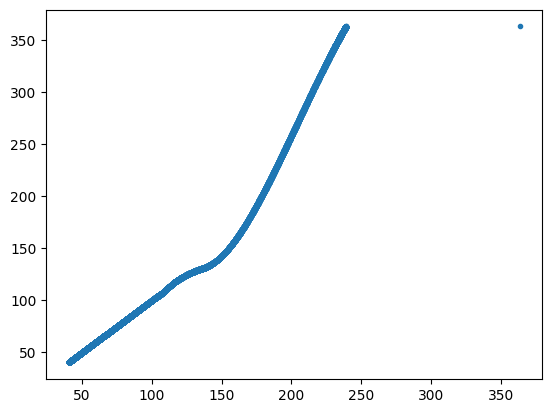

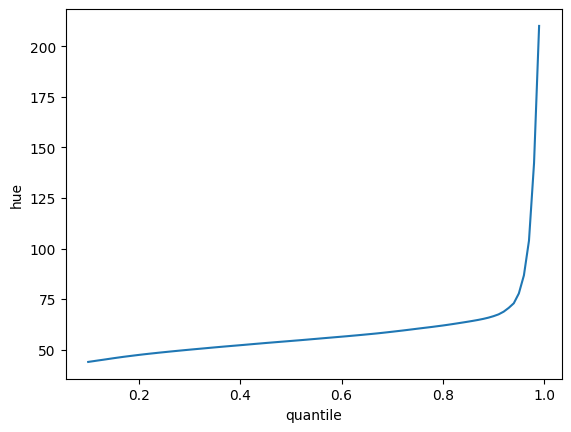

In [237]:
plt.scatter(ds[name].where(ds[inst]==True).where(ds.water_5yr==True),ds[name+'_'+inst+'_h'],marker='.')
plt.show()
ds[name].where(ds[inst]==True).where(ds.water_5yr==True).quantile(np.arange(0.1,1,0.01)).plot()
#plt.scatter(ds[name].where(ds[inst]==True).where(ds.water_5yr==True),ds[name].where(ds[inst]==True).where(ds.water_5yr==True))


hue_msi hue_msi


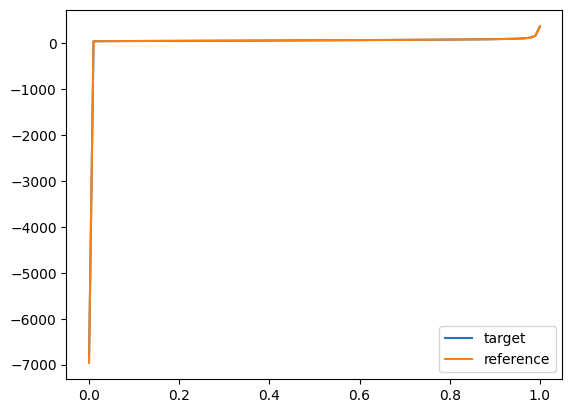

AttributeError: module 'matplotlib.pyplot' has no attribute 'ylim'

In [911]:
# --- 'harmonise_for_instrument' adjusts the values of an array  ----
# the adjustment ensures that, statistically, the returned values have the same distribution (mean, variance) as the reference
# 

if True:
    target = 'hue_msi'
    reference = 'hue_msi'

    refname = lookup[lookup.target==target]['reference'].item()
    print(target,refname)
    Q              = distributions.q 
    target_dist    = distributions[target]

    reference_dist = distributions[refname]
    method = 'quadratic'
    # --- fit a model to X; ie Q = f(x)
    f = sp.interpolate.interp1d(target_dist,Q,kind=method,fill_value='extrapolate')
    # --- fit an inverse model to Y; ie Y = g(Q)
    g = sp.interpolate.interp1d(Q,reference_dist,kind=method,fill_value='extrapolate')
    # --- new values are given by g(f(x)), which is very cool 
    
    # --- create a new variable as a data array that matches the one provided, so that we can return a nice arra
    
plt.plot(Q,target_dist,label='target')
plt.plot(Q,reference_dist,label='reference')
plt.legend()
plt.show()
data_range = np.arange(0,150,1)
plt.ylim(-10,10)

plt.plot(data_range,data_range,label='y=x')
#plt.plot(data_range,g(f(data_range)),label='round_trip')
plt.show()

In [910]:
del plt.ylim

In [818]:
xr.where(ds.where(ds.water_5yr==True)[inst]==True,ds.hue,ds.hue)

<xarray.DataArray (time: 212, y: 156, x: 81)> Size: 21MB
array([[[ 59.32952066,  58.23493605,  58.23493605, ...,  63.8627789 ,
         106.52854128,  69.62111811],
        [ 57.81737505,  56.78588644,  56.78588644, ...,  93.4094712 ,
         190.8063829 , 193.39914334],
        [ 62.71653283,  61.17448258,  61.17448258, ..., 111.00144723,
         203.40071073,  85.25825864],
        ...,
        [ 60.65955407,  60.65955407,  54.126691  , ...,  64.99910025,
          64.93872886,  64.93872886],
        [ 55.6405084 ,  55.6405084 ,  57.09596075, ...,  65.1991776 ,
          65.16693831,  65.16693831],
        [ 55.47299364,  55.47299364,  55.49477329, ...,  65.39559755,
          64.98690525,  64.98690525]],

       [[ 45.71040517,  51.83593052,  43.14710415, ...,  58.86173274,
          59.16214068,  60.68740045],
        [ 42.83831415,  57.32466374,  51.2366461 , ...,  57.57244872,
          56.2653467 ,  57.71857002],
        [ 58.13246822,  56.72375696,  58.47831091, ...,  55.14395768,
          57.36948313,  56.15076677],
...
        [ 40.60022268,  42.64678563,  40.05513813, ...,  62.19318886,
          60.56107167,  59.2653063 ],
        [ 40.60022268,  42.64678563,  40.05513813, ...,  59.66279037,
          64.46213618,  67.32565042],
        [ 42.53976982,  44.21725397,  40.49510932, ...,  59.66279037,
          64.46213618,  67.32565042]],

       [[ 40.19502676,  37.83331304,  40.06094693, ...,          nan,
                  nan,          nan],
        [ 41.48849807,  44.3634954 ,  48.66728029, ...,          nan,
                  nan,          nan],
        [ 44.64402055,  46.52121386,  49.86822602, ...,          nan,
                  nan,          nan],
        ...,
        [ 54.17809715,  46.87251063,  40.14026155, ...,          nan,
                  nan,          nan],
        [ 39.59801698,  43.70501524,  44.15731692, ...,          nan,
                  nan,          nan],
        [ 39.59801698,  43.70501524,  44.15731692, ...,          nan,
                  nan,          nan]]], shape=(212, 156, 81))
Coordinates:
  * time         (time) datetime64[ns] 2kB 2019-01-01T07:35:48.986888 ... 202...
  * y            (y) float64 1kB -1.868e+06 -1.868e+06 ... -1.831e+06 -1.831e+06
  * x            (x) float64 648B 3.392e+06 3.392e+06 ... 3.411e+06 3.411e+06
    spatial_ref  int32 4B 6933

In [797]:
new.mean(dim='time')

<xarray.DataArray 'hue_h' (y: 156, x: 81)> Size: 101kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(156, 81))
Coordinates:
  * y            (y) float64 1kB -1.868e+06 -1.868e+06 ... -1.831e+06 -1.831e+06
  * x            (x) float64 648B 3.392e+06 3.392e+06 ... 3.411e+06 3.411e+06
    spatial_ref  int32 4B 6933

In [761]:
for inst in 'tm'.ds.hue.mean(dim=('x','y'))

In [764]:
ds0.hue.where(ds0['tm'] == True,-1)

<xarray.DataArray 'hue' (time: 212, y: 156, x: 81)> Size: 21MB
array([[[ 59.32952066,  58.23493605,  58.23493605, ...,  63.8627789 ,
         106.52854128,  69.62111811],
        [ 57.81737505,  56.78588644,  56.78588644, ...,  93.4094712 ,
         190.8063829 , 193.39914334],
        [ 62.71653283,  61.17448258,  61.17448258, ..., 111.00144723,
         203.40071073,  85.25825864],
        ...,
        [ 60.65955407,  60.65955407,  54.126691  , ...,  64.99910025,
          64.93872886,  64.93872886],
        [ 55.6405084 ,  55.6405084 ,  57.09596075, ...,  65.1991776 ,
          65.16693831,  65.16693831],
        [ 55.47299364,  55.47299364,  55.49477329, ...,  65.39559755,
          64.98690525,  64.98690525]],

       [[ -1.        ,  -1.        ,  -1.        , ...,  -1.        ,
          -1.        ,  -1.        ],
        [ -1.        ,  -1.        ,  -1.        , ...,  -1.        ,
          -1.        ,  -1.        ],
        [ -1.        ,  -1.        ,  -1.        , ...,  -1.        ,
          -1.        ,  -1.        ],
...
        [ 40.60022268,  42.64678563,  40.05513813, ...,  62.19318886,
          60.56107167,  59.2653063 ],
        [ 40.60022268,  42.64678563,  40.05513813, ...,  59.66279037,
          64.46213618,  67.32565042],
        [ 42.53976982,  44.21725397,  40.49510932, ...,  59.66279037,
          64.46213618,  67.32565042]],

       [[ 40.19502676,  37.83331304,  40.06094693, ...,          nan,
                  nan,          nan],
        [ 41.48849807,  44.3634954 ,  48.66728029, ...,          nan,
                  nan,          nan],
        [ 44.64402055,  46.52121386,  49.86822602, ...,          nan,
                  nan,          nan],
        ...,
        [ 54.17809715,  46.87251063,  40.14026155, ...,          nan,
                  nan,          nan],
        [ 39.59801698,  43.70501524,  44.15731692, ...,          nan,
                  nan,          nan],
        [ 39.59801698,  43.70501524,  44.15731692, ...,          nan,
                  nan,          nan]]], shape=(212, 156, 81))
Coordinates:
  * time         (time) datetime64[ns] 2kB 2019-01-01T07:35:48.986888 ... 202...
  * y            (y) float64 1kB -1.868e+06 -1.868e+06 ... -1.831e+06 -1.831e+06
  * x            (x) float64 648B 3.392e+06 3.392e+06 ... 3.411e+06 3.411e+06
    spatial_ref  int32 4B 6933

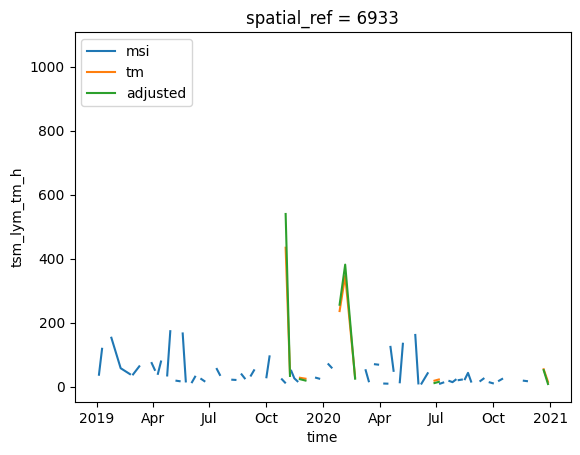

In [751]:
ds.tsm_lym_msi.mean(dim=('x','y')).plot(label='msi')
ds.tsm_lym_tm.mean(dim=('x','y')).plot(label='tm')
harmonise_for_instrument(ds.tsm_lym_tm,'tsm_lym_tm',lookup,distributions).mean(dim=('x','y')).plot(label='adjusted')
plt.legend()
plt.show()

##### Look at some results

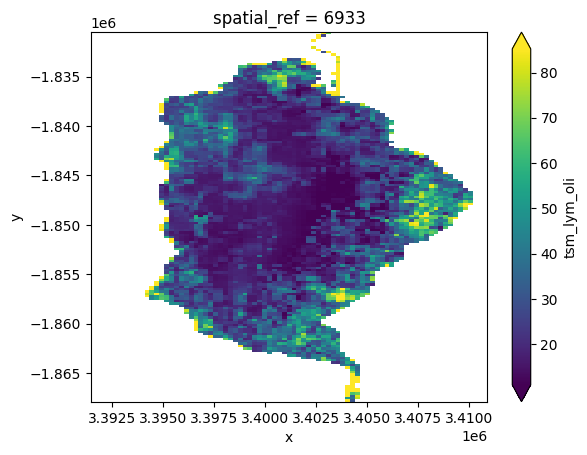

In [668]:
ds.tsm_lym_oli.mean(dim='time').plot(robust=True)

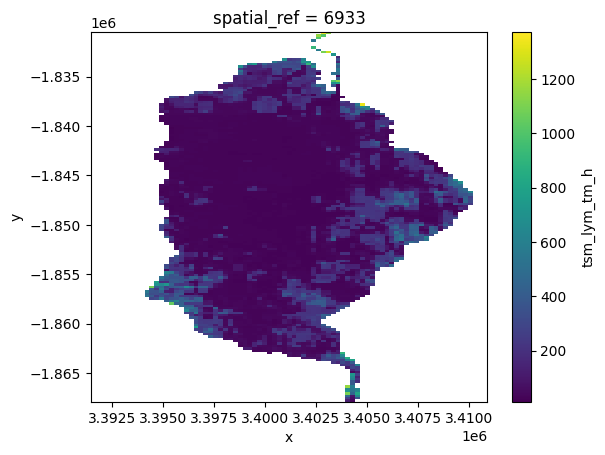

In [627]:
ds.tsm_lym_tm_h.mean(dim='time').plot(); 
ds.tsm_lym_tm_h.mean(dim='time').plot(); 

In [ ]:
# Apply the function to a variable from the annual dataset...

### Visualisations used to examine the distributions and choose the reference variable in each case
- The MSI instrument is generally used as the reference instrument.

MSI:
- produces the most data, and;
- generally produces the distributions which have fewest extremes, and;
- produces data with high variance through normal values (variance indicates potential to differentiate) .


##### Look at results for a specific site(s):

In [ ]:
# --- display results for some sites and variables
placename = 'Haartbeesport_dam'
placename = 'HC_1'
placename = 'HC_2'
placename = 'HC_3'
placename = 'HC_4'
placename = 'HC_5'
placename = 'HC_6'
results_directory = '/home/jovyan/deafrica_water_quality/wq_results/'
parta_results_filename   = '22A'
pathname = results_directory
filename = parta_results_filename+'_'+placename

dsr = read_statsfile(filename,pathname)

# selecting the reference distribution for the ndci variables..

for i in np.arange(15,wq_stats.place.size):
    placename = wq_stats.place[i]
    for instr in ['ndssi_rg_msi'  , 'ndssi_rg_oli', 'ndssi_rg_tm', 'ndssi_bnir_oli'] :
        wq_stats.loc[{'place':placename,'q':wq_stats.q[5:95]}][instr].plot(label=instr)
    plt.legend()
    plt.show()
#conclude that msi54 is the best distribution for haarteesport dam

##### Look at results across all sites:

['tss_grb']


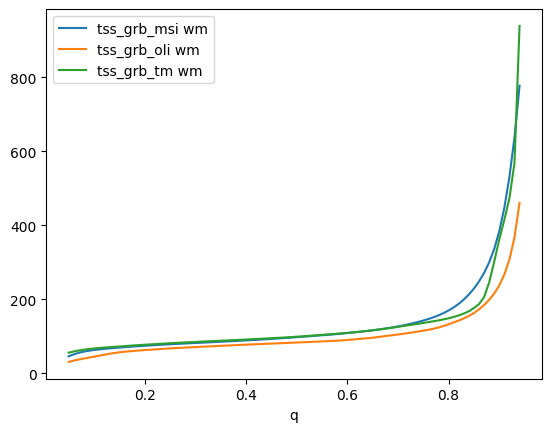

In [671]:
# --- visualise results for selected variables across all test sites...

mmt={}
mmt['ndci']         = ['ndci_msi54', 'ndci_msi64', 'ndci_msi74', 'ndci_tm43','ndci_oli54']
mmt['chla_toming']  = ['chla_toming_msi']
mmt['chla_3bda']    = ['chla_3bda_msi', 'chla_3bda_oli','chla_3bda_tm']
mmt['chla_tebbs']   = ['chla_tebbs_msi', 'chla_tebbs_oli','chla_tebbs_tm']
mmt['chla_meris2b'] = ['chla_meris2b_msi', 'chla_modis2b_msi','chla_modis2b_tm']
mmt['ndssi_rg']     = ['ndssi_rg_msi'  , 'ndssi_rg_oli', 'ndssi_rg_tm', 'ndssi_bnir_oli']
mmt['ti_yu']        = ['ti_yu_oli', 'ti_yu_tm']
mmt['tsm_lym']      = ['tsm_lym_oli','tsm_lym_msi','tsm_lym_tm']
mmt['tss_grb'] = ['tss_grb_msi', 'tss_grb_oli','tss_grb_tm']
mmt['tss_gr']  = ['tss_gr_msi', 'tss_gr_oli', 'tss_gr_tm']
mmt['spm_qiu'] = ['spm_qiu_tm', 'spm_qiu_msi']
mmt['fai']     = ['fai_tm', 'fai_oli', 'fai_msi']
mmt['ndvi']    = ['ndvi_tm', 'ndvi_oli', 'ndvi_msi']
mmt['hue']     = ['hue_tm', 'hue_oli', 'hue_msi']

measurements = list(mmt.keys())
measurements = ['ndci']
i = 8

q0 = 5
q1 = 95
measurements = [list(mmt.keys())[i]]
print(measurements)
for m in list(measurements):
    for variable in mmt[m]:
#        wq_stats.loc[{'q':wq_stats.q[q0:q1]}][variable].mean(dim='place').plot(label=variable)
        ((wq_stats.loc[{'q':wq_stats.q[q0:q1]}][variable] * wq_stats.n).sum(dim='place') / wq_stats.n.sum()).plot(label=variable+' wm',linestyle='-',marker='')
                                                                                                                  

    plt.legend()
    plt.show()
i += 1
#conclude that msi54 is the best distribution for haarteesport dam

# Part B, Measurement to Measurement Harmonisation

In [231]:
# --- operating parameters and dictionary of places ---


In [232]:
# --- controlling parameters and settings
verbose = True
test    = False
max_cells = 100000   #use this to test memory limits. Memory saving steps are going to be needed...
max_cells = 10000   #use this to test memory limits. Memory saving steps are going to be needed... (Results are not particularly sensitive to cell size)


In [ ]:
# --- set which instruments to use (this is checked later against the date range for each place)
# --- for Phase1, mapping, the main datasets are the geomedians. For monioring the local time-seres will be brought in as well as the geomedians.
# --- temperature is yet to be included.

instruments_to_use = {
    'oli_agm'  : {'use': True },
    'oli'      : {'use': False},
    'msi_agm'  : {'use': True },
    'msi'      : {'use': False},
    'tm_agm'   : {'use': True },
    'tm'       : {'use': False},
    'tirs'     : {'use': False},  
    'wofs_ann' : {'use': True },
    'wofs_all' : {'use': False },  # wofs_all will be removed as it is better to derive from wofs_ann
    }

year1 = '2000'
year2 = '2024'
# --- don't try to use instruments for which there are no data 
instruments_to_use = check_instrument_dates(instruments_to_use,int(year1),int(year2),verbose=False)

# --- retain a dictionary of the instruments and measurements that are on-hand ---
instruments    = instruments_list(instruments_to_use)[0]  # a list of the instruments  in use
            
# --- get the dictionary of all possible places for analysis ---
places_dict     = set_spacetime_domain()   

In [ ]:
# --- start the log file and parameters dictionary --- 

logfilename = 'log.csv'
open_logfile(places_dict,logfilename,overwrite='Append')
log

## B-1 Run the geomedian analysis for all target sites
- the process runs only for those sites in the log file that have status < 100
- the results for each waterbody / target area are saved as a netcdf file
- in part B-2 these files are read back in for comparison

In [378]:
# --- run the process for all places in the log file...
over_write = False # to overwrite previous results
verbose    = False
for placename in places_dict.keys():
    if places_dict[placename]['run'] == True:
        if log.loc[log.PlaceName==placename,'Status'].item() < 100 :
            print(placename)
            results_filename = all_results_filename+'_'+placename+'.nc'
            spacetime_domain, grid_resolution, cell_area, resampling_option, year1, year2 \
                           = set_spacetime_domain(placename,year1,year2,max_cells,verbose,False)
            parameters = store_parameters(placename,
                                          spacetime_domain,
                                          grid_resolution,
                                          cell_area,
                                          resampling_option,
                                          year1,
                                          year2)
            i = 1 
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                log = log_parameters(log,placename,parameters)
            # check to see if the outputs already exist and if so reset the status value
            if os.path.exists(results_directory+results_filename) : 
                if not over_write :
                    log = log_update(log,placename,100)
            i+=1 
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                ds             = build_wq_agm_dataset(spacetime_domain,instruments_to_use,verbose = verbose)
                log = log_update(log,placename,i)        
            i+=1 
            if log.loc[a_log.PlaceName==placename,'Status'].item() <i:
                ds_annual = detect_geomedian_instruments(ds_annual)
                log     = log_update(log,placename,i,logfilename)
            i+=1
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                ds  = calculate_agm_count(ds)
            i+=1
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                # --- controling parameters for water mapping on a pixel by pixel basis ---
                WFTH = water_frequency_threshold_high = 0.5    #this threshold targets areas that are as like as not to be water at any time.
                PWT  = permanent_water_threshold      = 0.875  #used to map annual permanent water (value arrived at through testing)
                SC   = sigma_coefficient              = 1.2    #used to map annual permanent water (value arrived at through tessting)
                ds   = water_analysis(ds,
                   water_frequency_threshold= WFTH,
                   wofs_varname             = 'wofs_ann_freq',
                   permanent_water_threshold= PWT,
                   sigma_coefficient        = SC,
                   verbose                  = True,
                   test                     = test)
                ds              = WOFS_5_year_frequency(ds,False)
                ds['water_5yr'] = xr.where(ds.wofs_5yr_freq>0.45,ds.wofs_5yr_freq.astype('bool'),np.nan)
                ds              = detect_geomedian_instruments(ds)
                # results is a dictionary that contains the parameters and a dataframe of annual results
                results         = initiate_results_dictionary(ds,parameters)
                ds              = geomedian_FAI(ds,ds.water_5yr)
                ds              = set_clearwater(ds)
                log = log_update(log,placename,i)        
            i+=1
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                ds              = apply_R_correction(ds,['msi_agm','oli_agm','tm_agm'],
                                                 water_mask=ds.water_5yr,drop = True, 
                                                 test = False,verbose=False)
                
                log = log_update(log,placename,i)        
            i +=1
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
            
                ds = geomedian_hue(ds,ds.clearwater==True,test=True,verbose=True)
                ds = run_OWT(ds)
                log = log_update(log,placename,i)                      
            i +=1
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                algorithms_chla,algorithms_tsm = set_wq_algorithms(suffix='_agm')
                ds,tsm_vlist  = WQ_vars(ds.where(ds.clearwater),
                        algorithms_tsm,  
                        instruments, 
                        new_dimension_name='tss_measure', 
                        new_varname='tss', 
                        verbose=verbose)
                ds,chla_vlist = WQ_vars(ds.where(ds.clearwater),
                        algorithms_chla, 
                        instruments, 
                        new_dimension_name='chla_measure', 
                        new_varname='chla',
                        verbose=verbose)
                log = log_update(log,placename,i)                      
            i +=1
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                wq_results = calc_statistics(ds,placename)
                log = log_update(log,placename,i)                      
            i +=1
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                save_results(wq_results,results_filename,results_directory)
                log = log_update(log,placename,i)       
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                print(' this should not happen')
            else : 
                print('end of process for place = '+placename+'. Setting status to 100')
                log = log_update(log,placename,100)       
                


In [379]:
log[log.PlaceName=='Lake_Baringo']

,Unnamed: 0,PlaceName,Status,RunNumber,Year1,Year2,x0,x1,y0,y1,t0,t1,CellArea,Resampling
0,0,Lake_Baringo,100,63,2000,2024,36.0,36.17,0.45,0.74,2000,2024,0.0484,nearest


## B-2 Read in results from an annual geomedian analysis
- the results from each waterbody / target area are read and merged to a single working dataset
- using the statistics from all the study areas, global adjustments are derived for each measurement to match a chosen reference
- the simplest form of those adjustments is a scale and shift. This is also very defensible since the underlying assumptions are minimal

### Read and merge results files :

In [355]:
# --- merge the results file to a single dataset. 
# Note that writing a large file to netcdf and then readin back in loses information
# The place names get truncated for some reason. For that reason, I keep them all separate and merge
wq_results = merge_results(log,all_results_filename,results_directory)

### Calculate the of scale and offset parameters for each instument :

In [414]:
wq_results = calc_scale_and_offset(wq_results,verbose=False)

### Inspect results :


#### Chl-A :


Senegal_StLouis


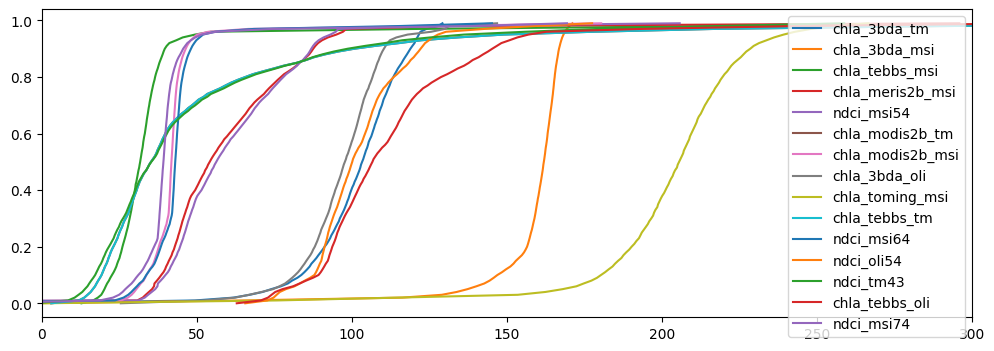

In [623]:
# --- check some of the results ---
#     a little bit of analysis and normalisation to be able to view the results comparatively
rng = np.random.default_rng()
i = rng.integers(size=1,low=0,high=wq_results.place.size).item()
placename = wq_results.place[i].item()
#print(placename)


    
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
plt.xlim(0,300)

exclude = ['chla_tebbs_oli','chla_tebbs_msi','chla_tebbs_tm']
exclude = []

reftime    =  wq_results.time[0:24]   
targettime =  wq_results.time[0:24]  
displaytime = wq_results.time[0:24]

print(placename)

for name in (set(wq_results.chla_measure.values) - set(exclude)):
    scale  =  wq_results.loc[dict(chla_measure = name)].chla_scale.item()
    offset =  wq_results.loc[dict(chla_measure = name)].chla_offset.item()
    #print(scale,offset)
    y = wq_results['quantile'][wq_results['quantile']<1]
    x = ((wq_results.loc[dict(time = (displaytime) ,
                             chla_measure=name ,
                             place = placename,
                             quantile=(wq_results['quantile'] <1))].chla\
                             * scale) + offset).median(dim=('time'))
    plt.plot(x,y,label=name)
plt.legend(loc='best')
plt.show()


Kolokonda


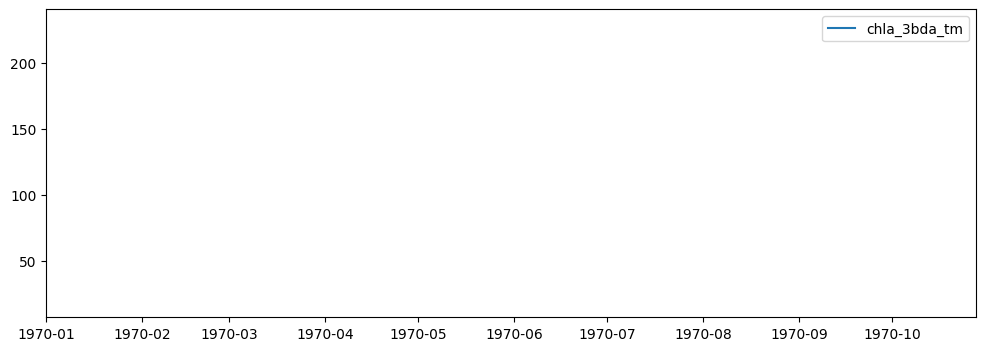

In [630]:
# --- check some of the results ---
#     a little bit of analysis and normalisation to be able to view the results comparatively
rng = np.random.default_rng()
i = rng.integers(size=1,low=0,high=wq_results.place.size).item()
placename = wq_results.place[i].item()
#print(placename)


    
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
plt.xlim(0,300)

exclude = ['chla_tebbs_oli','chla_tebbs_msi','chla_tebbs_tm']
exclude = []

reftime    =  wq_results.time[0:24]   
targettime =  wq_results.time[0:24]  
displaytime = wq_results.time[0:25]

print(placename)

if True:
    #print(scale,offset)
    x = wq_results['time']
    y = ((wq_results.loc[dict(time = (displaytime) ,
                              place = placename,
                              quantile=(wq_results['quantile'] ==.5))].chla\
                             * wq_results.chla_scale) + wq_results.chla_offset).median(dim=('chla_measure')).squeeze()
    plt.plot(x,y,label=name)
plt.legend(loc='best')
plt.show()


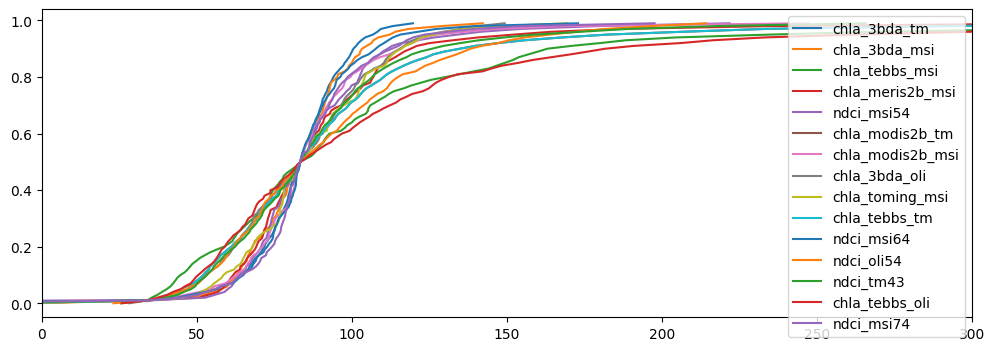

In [534]:
# --- check some of the results ---
#     a little bit of analysis and normalisation to be able to view the results comparatively
rng = np.random.default_rng()
i = rng.integers(size=1,low=0,high=wq_results.place.size).item()
    
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
plt.xlim(0,300)

exclude = ['chla_tebbs_oli','chla_tebbs_msi','chla_tebbs_tm']
exclude = []

reftime    =  wq_results.time[0:24]   
targettime =  wq_results.time[0:24]  
displaytime = wq_results.time[0:24]

for name in (set(wq_results.chla_measure.values) - set(exclude)):
    y = wq_results['quantile'][wq_results['quantile']<1]
    scale  = wq_results.loc[dict(chla_measure=name)].chla_scale
    offset = wq_results.loc[dict(chla_measure=name)].chla_offset
    
    x = (wq_results.loc[dict(time = (displaytime) ,
                             chla_measure=name ,
                             quantile=(wq_results['quantile'] <1))].chla.
                             median(dim=('time','place')) * scale) + offset
    plt.plot(x,y,label=name)
plt.legend(loc='best')
plt.show()


#### Demonstrates the *dynamic application* of the scale and offset parameters:

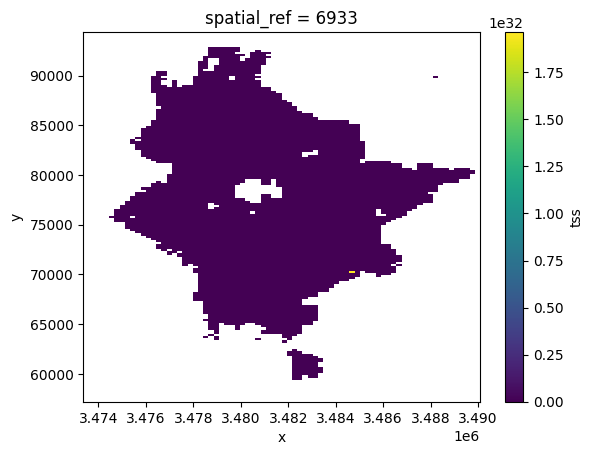

In [542]:
ds.tss.mean(dim=('time','tss_measure')).plot()

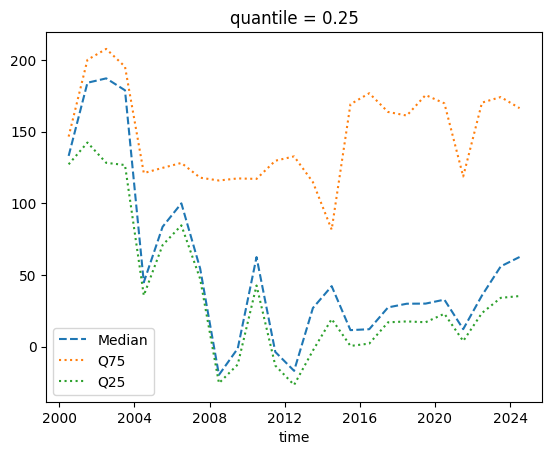

In [480]:
(ds.chla * wq_results.chla_scale + wq_results.chla_offset).median(dim=('chla_measure','x','y')).plot(linestyle = '--',label='Median')
(ds.chla * wq_results.chla_scale + wq_results.chla_offset).quantile(0.75,dim=('chla_measure','x','y')).plot(linestyle=':',label='Q75')
(ds.chla * wq_results.chla_scale + wq_results.chla_offset).quantile(0.25,dim=('chla_measure','x','y')).plot(linestyle=':',label='Q25')
plt.legend(loc='best')

In [609]:
wq_results.

<xarray.DataArray 'chla_measure' (chla_measure: 15)> Size: 960B
array(['ndci_msi54', 'ndci_msi64', 'ndci_msi74', 'ndci_tm43', 'ndci_oli54',
       'chla_toming_msi', 'chla_3bda_msi', 'chla_3bda_oli', 'chla_3bda_tm',
       'chla_tebbs_msi', 'chla_tebbs_oli', 'chla_tebbs_tm', 'chla_meris2b_msi',
       'chla_modis2b_msi', 'chla_modis2b_tm'], dtype='<U16')
Coordinates:
  * chla_measure  (chla_measure) <U16 960B 'ndci_msi54' ... 'chla_modis2b_tm'
    spatial_ref   int32 4B 6933

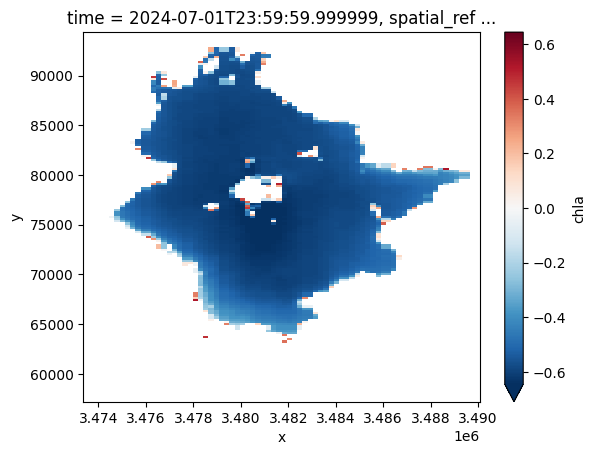

In [614]:
# --- the process seems to be working the way it ought...

(ds.chla* 1 + 0).isel(time=24).loc[dict(chla_measure='chla_modis2b_oli')].plot(robust=True)

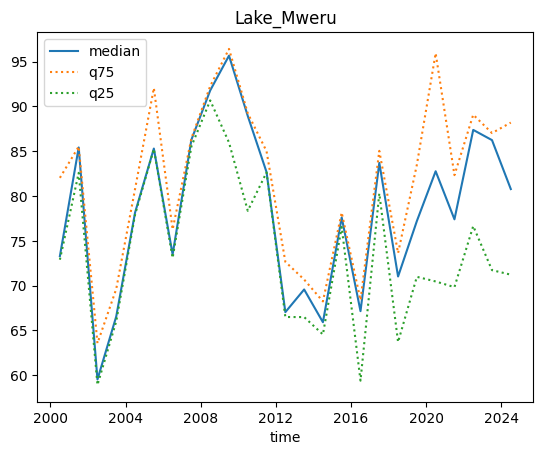

In [662]:
i = i
placename = wq_results.place[i].item()
(wq_results.chla.loc[dict(quantile=(wq_results['quantile'] ==.5))] * wq_results.chla_scale + wq_results.chla_offset).\
    squeeze().sel(place=placename).quantile(0.5,dim='chla_measure').plot(label='median')
(wq_results.chla.loc[dict(quantile=(wq_results['quantile'] ==.5))] * wq_results.chla_scale + wq_results.chla_offset).\
    squeeze().sel(place=placename).quantile(0.75,dim='chla_measure').plot(label='q75',linestyle=':')
(wq_results.chla.loc[dict(quantile=(wq_results['quantile'] ==.5))] * wq_results.chla_scale + wq_results.chla_offset).\
    squeeze().sel(place=placename).quantile(0.25,dim='chla_measure').plot(label='q25',linestyle=':')
plt.title(placename)
plt.legend()
plt.show()
i+=1

/opt/venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/opt/venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/opt/venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


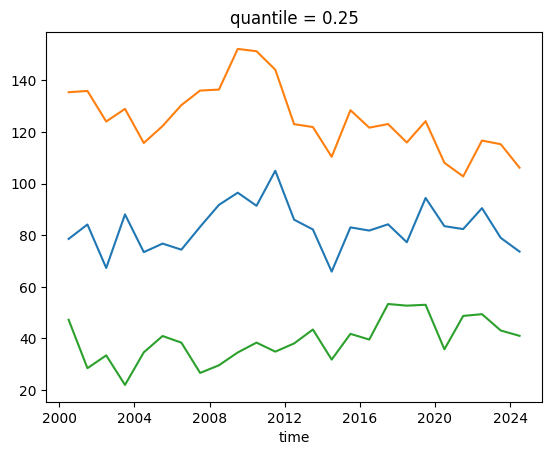

In [589]:
(wq_results.chla.loc[dict(quantile=(wq_results['quantile'] ==.5))] * wq_results.chla_scale + wq_results.chla_offset).\
    squeeze().\
    quantile(0.5,dim=('chla_measure')).\
    quantile(0.75,dim=('place')).plot()
(wq_results.chla.loc[dict(quantile=(wq_results['quantile'] ==.5))] * wq_results.chla_scale + wq_results.chla_offset).\
    squeeze().\
    quantile(0.5,dim=('chla_measure')).\
    quantile(0.25,dim=('place')).plot()

                                   

#### TSS :


Ghana_River


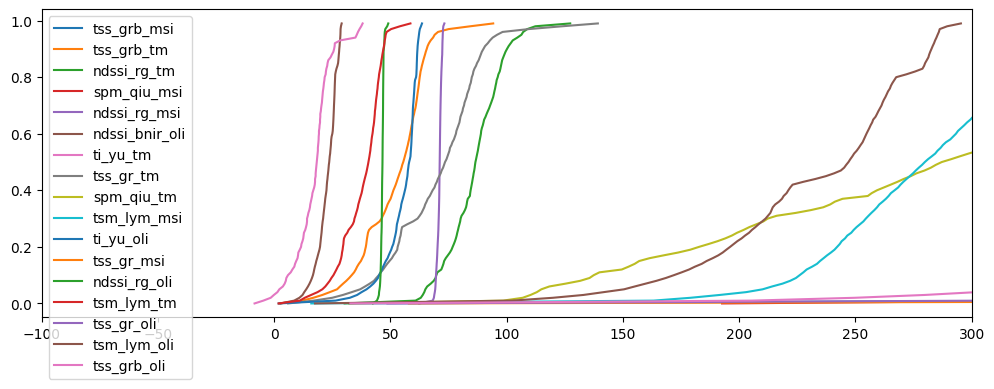

In [736]:
# --- check some of the results ---
#     a little bit of analysis and normalisation to be able to view the results comparatively
#rng = np.random.default_rng()
#i = rng.integers(size=1,low=0,high=wq_results.place.size).item()
i = i
placename = wq_results.place[i].item()
#print(placename)


    
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
plt.xlim(-100,300)

exclude = ['chla_tebbs_oli','chla_tebbs_msi','chla_tebbs_tm']
exclude = []

reftime    =  wq_results.time[0:24]   
targettime =  wq_results.time[0:24]  
displaytime = wq_results.time[0:24]

print(placename)

for name in (set(wq_results.tss_measure.values) - set(exclude)):
    scale  =  wq_results.loc[dict(tss_measure = name)].tss_scale.item()
    offset =  wq_results.loc[dict(tss_measure = name)].tss_offset.item()
    y = wq_results['quantile'][wq_results['quantile']<1]
    x = (wq_results.loc[dict(time = (displaytime) ,
                             tss_measure=name ,
                             place = placename,
                             quantile=(wq_results['quantile'] <1))].tss.
                             median(dim=('time')) * scale) + offset
    plt.plot(x,y,label=name)
plt.legend(loc='best')
plt.show()
i +=1

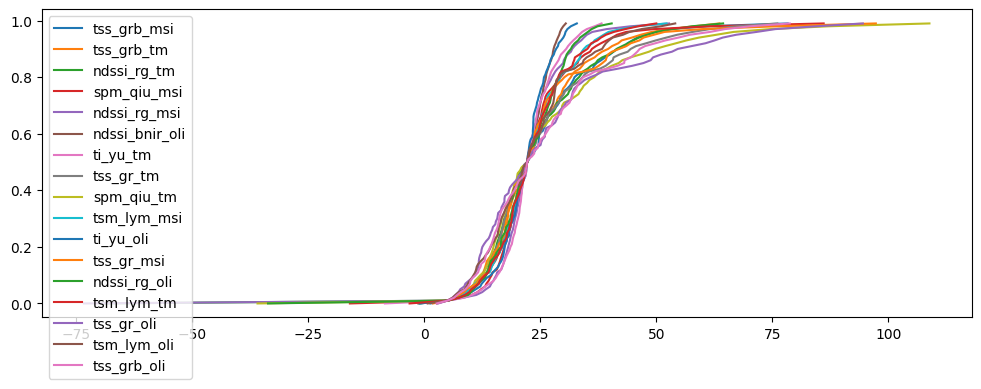

In [741]:
# --- check some of the results ---
#     a little bit of analysis and normalisation to be able to view the results comparatively
   
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
#plt.xlim(0,300)

exclude = []

reftime    =  wq_results.time[0:24]   
targettime =  wq_results.time[0:24]  
displaytime = wq_results.time[0:24]

for name in (set(wq_results.tss_measure.values) - set(exclude)):
    y = wq_results['quantile'][wq_results['quantile']<1]
    scale  = wq_results.loc[dict(tss_measure=name)].tss_scale
    offset = wq_results.loc[dict(tss_measure=name)].tss_offset
    

    x = (wq_results.loc[dict(time = (displaytime) ,
                             tss_measure=name ,
                             quantile=(wq_results['quantile'] <1))].tss.
                             median(dim=('time','place')) * scale) + offset
    plt.plot(x,y,label=name)
plt.legend(loc='best')
plt.show()


In [721]:
log[log.PlaceName=='Barrage Joumine']

,Unnamed: 0,PlaceName,Status,RunNumber,Year1,Year2,x0,x1,y0,y1,t0,t1,CellArea,Resampling
47,47,Barrage Joumine,100,110,2000,2024,9.53,9.62,36.952,37.0,2000,2024,0.0025,bilinear
